<a href="https://colab.research.google.com/github/shreetishresthanp/ml_theory/blob/main/homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem 2

In [86]:
import torch
import math
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### 2.a)
Load the MNIST dataset from pytorch. Here is an example code snippet for
loading the dataset into pytorch. Next, implement a fully-connected neural network with two layers, including one layer for producing the output logits in PyTorch. Report the final test accuracy. Plot the training loss and test accuracy curves.

In [87]:
def load_mnist ( batch_size =256) :
  """ Load and preprocess MNIST dataset """
  transform = transforms . Compose ([
  transforms . ToTensor () ,
  transforms . Normalize ((0.1307 ,) , (0.3081 ,) )
  ])
  train_dataset = torchvision . datasets . MNIST (
  root = "./ data" , train = True , download = True , transform =
  transform )
  test_dataset = torchvision . datasets . MNIST (
  root = "./ data" , train = False , download = True , transform =
  transform )
  train_loader = DataLoader ( train_dataset , batch_size = batch_size
  , shuffle = True )
  test_loader = DataLoader ( test_dataset , batch_size = batch_size ,
  shuffle = False )
  return train_loader , test_loader

In [88]:
class TwoLayerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(TwoLayerNet, self).__init__()
        # First fully-connected layer: 28*28 (784) input features to 128 intermediate features
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()

        # Second fully-connected layer: 128 intermediate features to 10 output features (for 10 classes)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Flatten the 28x28 image into a 784-element vector
        x = x.view(x.size(0), -1)
        # Pass through the first linear layer and apply ReLU activation
        x = self.fc1(x)
        x = self.relu(x)
        # Pass through the second linear layer to get the output logits
        x = self.fc2(x)
        return x

Functions for training the network (to calculate training loss) and evaluating it (to calculate test accuracy).


In [89]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backpropagation
        optimizer.step() # Update weights

        running_loss += loss.item() * inputs.size(0)

    # Return average loss for the epoch
    return running_loss / len(train_loader.dataset)

In [90]:
def evaluate_model(model, test_loader, device):
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1) # Get predicted class
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


Run Training Loop

In [91]:
def run_training_loop(hidden_dim, input_dim=784, output_dim=10,
                      num_epochs=10, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = TwoLayerNet(input_dim, hidden_dim, output_dim).to(device)

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_accuracies = [], []

    # Load MNIST dataset
    train_loader, test_loader = load_mnist(batch_size=256)

    print(f"Training on {device}")

    # Training loop
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        test_accuracy = evaluate_model(model, test_loader, device)
        train_losses.append(train_loss)
        test_accuracies.append(test_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

    print("Training complete.")

    return model, train_losses, test_accuracies

In [94]:
num_epochs = 10
model, train_losses, test_accuracies = run_training_loop(hidden_dim=128)

Training on cuda
Epoch [1/10], Loss: 0.3764, Test Accuracy: 94.05%
Epoch [2/10], Loss: 0.1665, Test Accuracy: 95.67%
Epoch [3/10], Loss: 0.1150, Test Accuracy: 96.73%
Epoch [4/10], Loss: 0.0878, Test Accuracy: 96.96%
Epoch [5/10], Loss: 0.0710, Test Accuracy: 97.25%
Epoch [6/10], Loss: 0.0578, Test Accuracy: 97.57%
Epoch [7/10], Loss: 0.0487, Test Accuracy: 97.41%
Epoch [8/10], Loss: 0.0411, Test Accuracy: 97.75%
Epoch [9/10], Loss: 0.0327, Test Accuracy: 97.81%
Epoch [10/10], Loss: 0.0284, Test Accuracy: 97.63%
Training complete.


In [95]:
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")

Final Test Accuracy: 97.63%


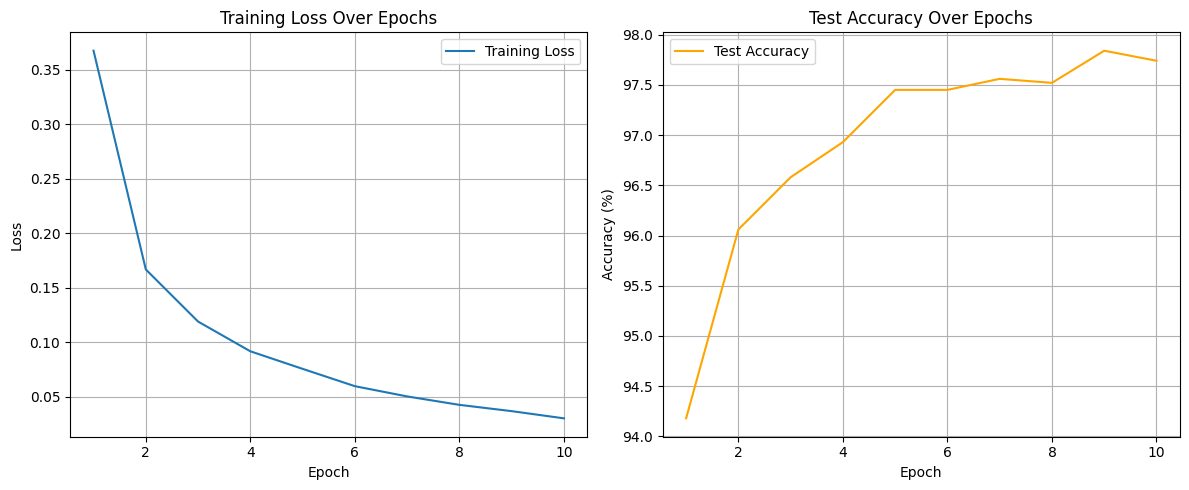

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)

# Plot Test Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 2.b)
Vary the width of the two-layer neural network between [50, 100, 150, 200] and
then report the training loss and test accuracy after varying the width. Compare the results
to the previous part. In addition, calculate the number of parameters used in each neural
network configuration.

In [ ]:
# baseline_results = {
#     'hidden_dim': 128,
#     'final_train_loss': 0.029878543229897817,
#     'final_test_accuracy': 97.62
# }

results = []

print("Baseline results stored and results list initialized.")

Baseline results stored and results list initialized.


In [ ]:
hidden_dims = [50, 100, 150, 200]
print(f"Hidden dimensions to test: {hidden_dims}")

Hidden dimensions to test: [50, 100, 150, 200]


In [ ]:
for current_hidden_dim in hidden_dims:
    print(f"\nTraining with hidden_dim = {current_hidden_dim}")
    model, train_losses, test_accuracies = run_training_loop(hidden_dim=current_hidden_dim)

    # 2.b (Calculate number of parameters)
    num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

    final_train_loss = train_losses[-1]
    final_test_accuracy = test_accuracies[-1]

    results.append({
        'model': model,
        'hidden_dim': current_hidden_dim,
        'final_train_loss': final_train_loss,
        'final_test_accuracy': final_test_accuracy,
        'num_parameters': num_parameters,
        'train_losses': train_losses,
        'test_accuracies': test_accuracies
    })

    print(f"  Final Loss: {final_train_loss:.4f}, Final Test Accuracy: {final_test_accuracy:.2f}%,")
    print(f"  Number of parameters: {num_parameters}")


Training with hidden_dim = 50
Training on cuda
Epoch [1/10], Loss: 0.4528, Test Accuracy: 93.01%
Epoch [2/10], Loss: 0.2281, Test Accuracy: 93.98%
Epoch [3/10], Loss: 0.1778, Test Accuracy: 95.14%
Epoch [4/10], Loss: 0.1475, Test Accuracy: 95.67%
Epoch [5/10], Loss: 0.1276, Test Accuracy: 96.04%
Epoch [6/10], Loss: 0.1118, Test Accuracy: 96.43%
Epoch [7/10], Loss: 0.1002, Test Accuracy: 96.64%
Epoch [8/10], Loss: 0.0897, Test Accuracy: 96.88%
Epoch [9/10], Loss: 0.0809, Test Accuracy: 96.89%
Epoch [10/10], Loss: 0.0735, Test Accuracy: 97.13%
Training complete.
  Final Loss: 0.0735, Final Test Accuracy: 97.13%,
  Number of parameters: 39760

Training with hidden_dim = 100
Training on cuda
Epoch [1/10], Loss: 0.3851, Test Accuracy: 93.57%
Epoch [2/10], Loss: 0.1832, Test Accuracy: 95.84%
Epoch [3/10], Loss: 0.1303, Test Accuracy: 96.59%
Epoch [4/10], Loss: 0.1013, Test Accuracy: 96.87%
Epoch [5/10], Loss: 0.0815, Test Accuracy: 97.00%
Epoch [6/10], Loss: 0.0689, Test Accuracy: 97.24%
Ep

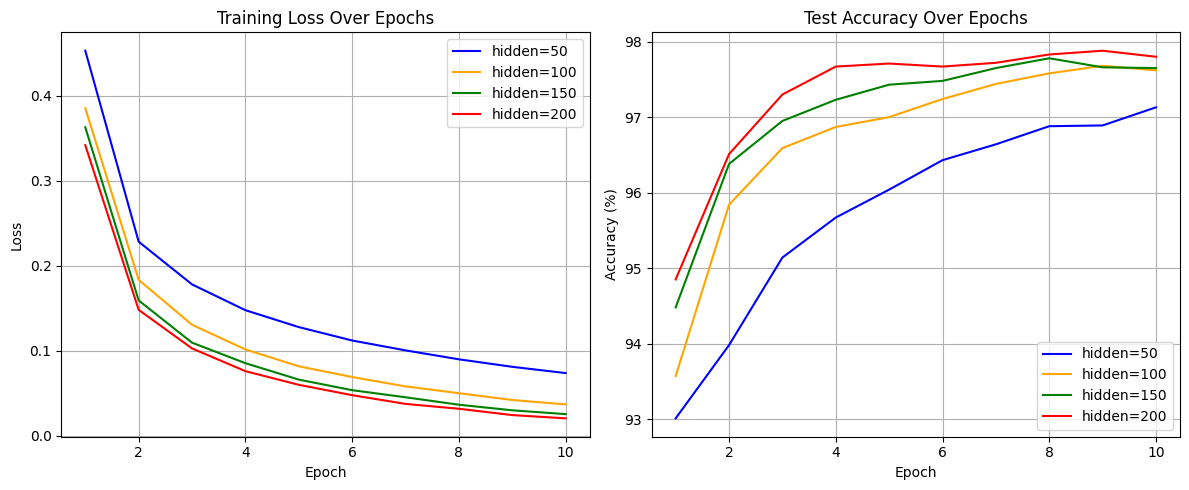

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['blue', 'orange', 'green', 'red']

for result, color in zip(results, colors):
    epochs = range(1, num_epochs + 1)
    axes[0].plot(epochs, result["train_losses"], label=f'hidden={result["hidden_dim"]}', color=color)
    axes[1].plot(epochs, result["test_accuracies"], label=f'hidden={result["hidden_dim"]}', color=color)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Epochs')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Hidden Dimension: 50
{'model': TwoLayerNet(
  (fc1): Linear(in_features=784, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=10, bias=True)
), 'hidden_dim': 50, 'final_train_loss': 0.07351718091964722, 'final_test_accuracy': 97.13, 'num_parameters': 39760, 'train_losses': [0.45276614581743874, 0.22809336790243784, 0.17781936631997428, 0.14751057359774908, 0.12761454844077427, 0.11183759034872055, 0.10022330282529195, 0.08971093825896581, 0.08087100498477617, 0.07351718091964722], 'test_accuracies': [93.01, 93.98, 95.14, 95.67, 96.04, 96.43, 96.64, 96.88, 96.89, 97.13]}


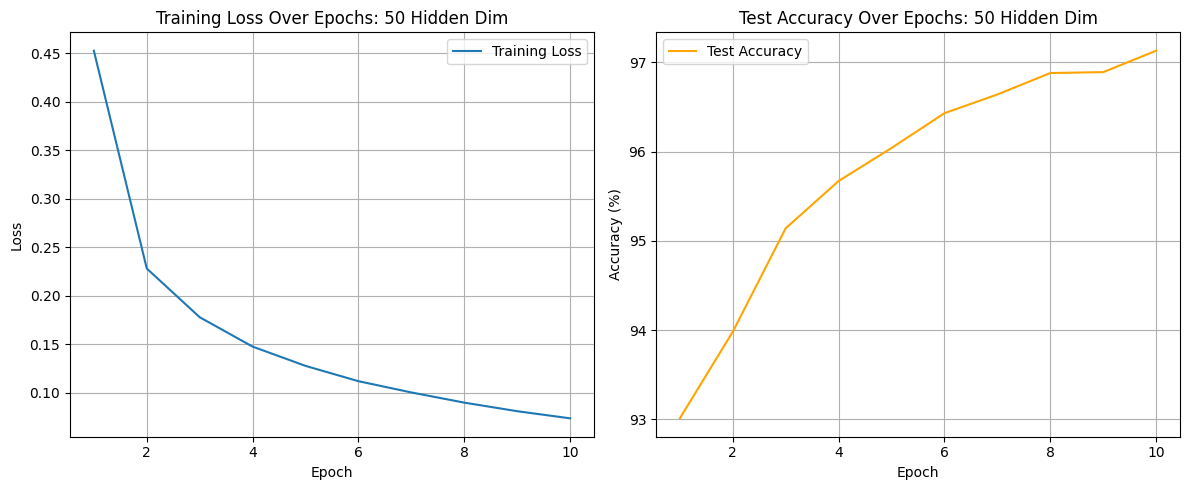

Hidden Dimension: 100
{'model': TwoLayerNet(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=10, bias=True)
), 'hidden_dim': 100, 'final_train_loss': 0.036655152608950935, 'final_test_accuracy': 97.62, 'num_parameters': 79510, 'train_losses': [0.3851493523597717, 0.18318238515853882, 0.13034731098016103, 0.10134444527427355, 0.08147435051401457, 0.06887877179781596, 0.05784269377787908, 0.049859560453891755, 0.041843855363130567, 0.036655152608950935], 'test_accuracies': [93.57, 95.84, 96.59, 96.87, 97.0, 97.24, 97.44, 97.58, 97.68, 97.62]}


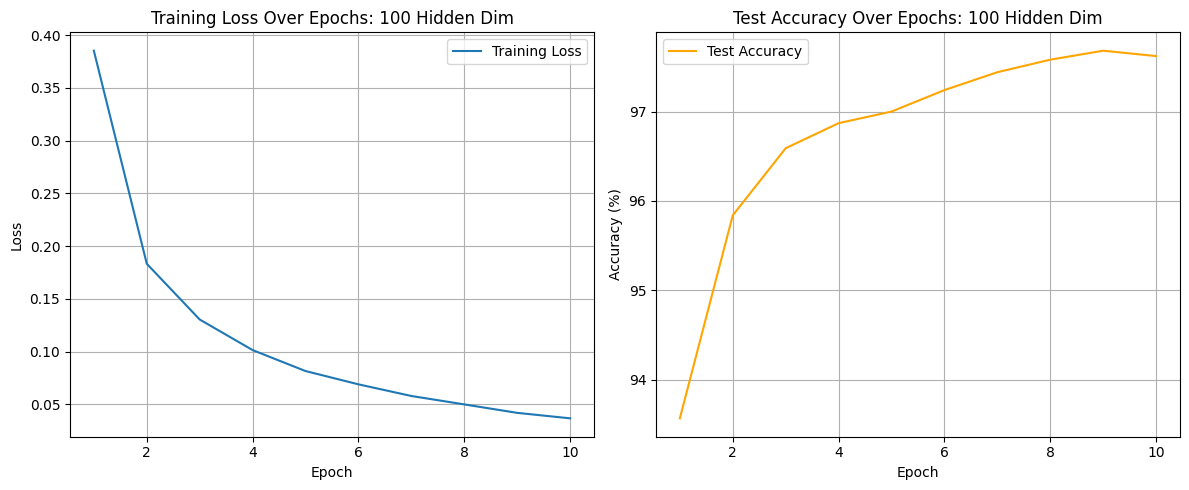

Hidden Dimension: 150
{'model': TwoLayerNet(
  (fc1): Linear(in_features=784, out_features=150, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=150, out_features=10, bias=True)
), 'hidden_dim': 150, 'final_train_loss': 0.025220355027914046, 'final_test_accuracy': 97.65, 'num_parameters': 119260, 'train_losses': [0.3626749968131383, 0.15898414789537588, 0.10928303475777308, 0.08514926796356836, 0.06581459061304729, 0.05339800279935201, 0.045038147016366326, 0.03628336755037308, 0.029702073641618094, 0.025220355027914046], 'test_accuracies': [94.48, 96.38, 96.95, 97.23, 97.43, 97.48, 97.65, 97.78, 97.66, 97.65]}


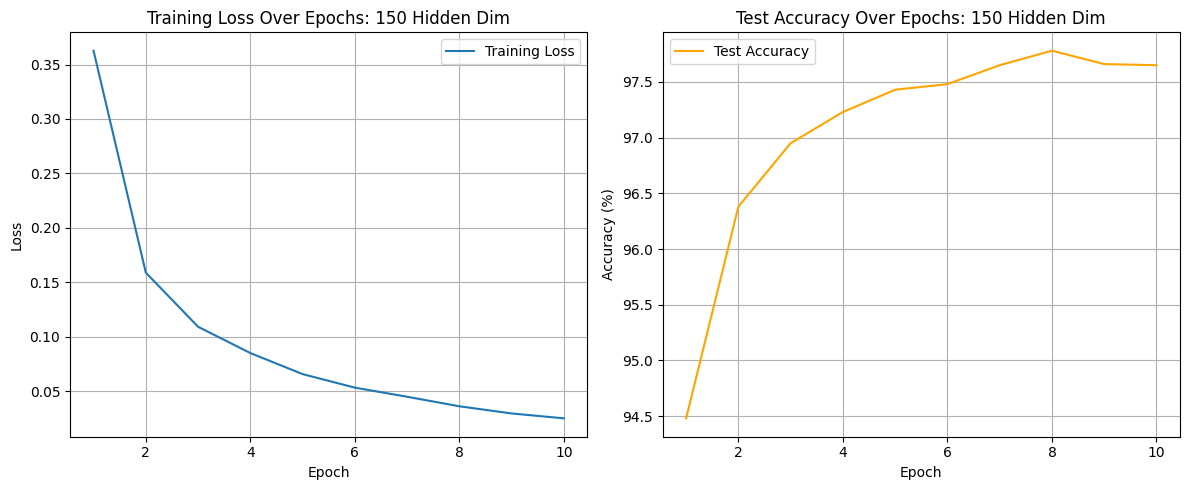

Hidden Dimension: 200
{'model': TwoLayerNet(
  (fc1): Linear(in_features=784, out_features=200, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=200, out_features=10, bias=True)
), 'hidden_dim': 200, 'final_train_loss': 0.02025531212389469, 'final_test_accuracy': 97.8, 'num_parameters': 159010, 'train_losses': [0.3416220855951309, 0.14790099965731304, 0.10250613270600636, 0.07576307305395603, 0.05971026399334272, 0.04750699060956637, 0.03724521508117517, 0.03152212554266055, 0.024087600188702346, 0.02025531212389469], 'test_accuracies': [94.85, 96.51, 97.3, 97.67, 97.71, 97.67, 97.72, 97.83, 97.88, 97.8]}


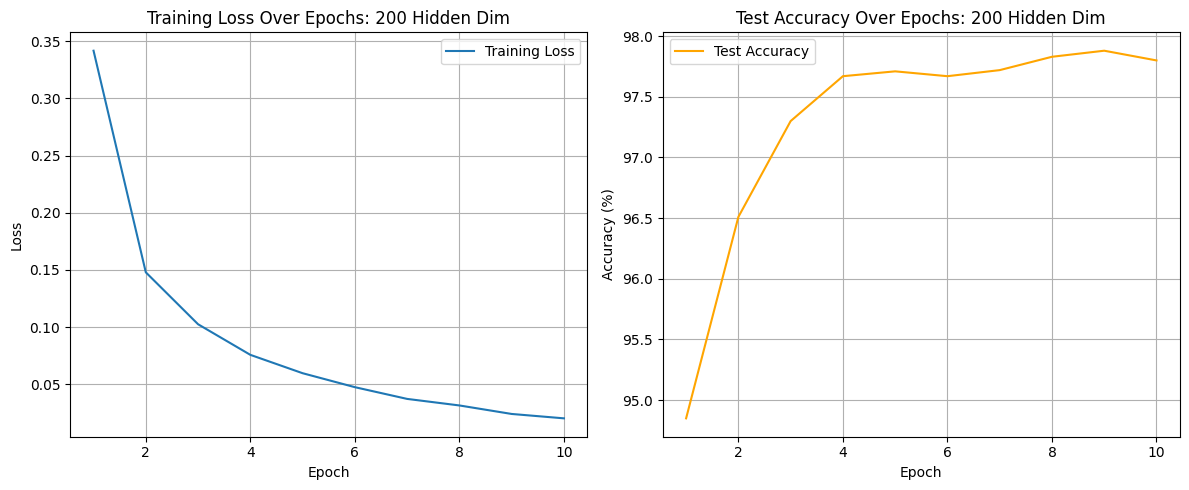

In [ ]:
for result in results:
  print(f"Hidden Dimension: {result['hidden_dim']}")
  print(result)
  plt.figure(figsize=(12, 5))

  # Plot Training Loss
  plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
  plt.plot(range(1, num_epochs + 1), result["train_losses"], label='Training Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(f'Training Loss Over Epochs: {result['hidden_dim']} Hidden Dim')
  plt.legend()
  plt.grid(True)

  # Plot Test Accuracy
  plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
  plt.plot(range(1, num_epochs + 1), result["test_accuracies"], label='Test Accuracy', color='orange')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.title(f'Test Accuracy Over Epochs: {result['hidden_dim']} Hidden Dim')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

### 2.c)
Measure the spectral norms of both layers of the trained two-layer neural network. Also, measure the path-norm of the trained two-layer neural network. Compare the spectral-norm generalization bound as well as the path-norm generalization bound in the trained model (recall Example 2.12 and the follow-up discussion from Lecture 8).



In [ ]:
import torch.linalg

def calculate_spectral_norm(layer):
    """
    Calculates the spectral norm of a PyTorch nn.Linear layer's weight matrix.
    """
    if isinstance(layer, nn.Linear):
        weight_matrix = layer.weight.detach().cpu()
        # SVD returns (U, S, Vh), where S contains the singular values
        singular_values = torch.linalg.svdvals(weight_matrix)
        spectral_norm = singular_values.max().item()
        return spectral_norm
    else:
        raise TypeError("Input must be an instance of torch.nn.Linear")

In [ ]:
def calculate_path_norm(model):
    w = model.fc2.weight.detach().cpu()  # shape: (10, hidden_dim)
    U = model.fc1.weight.detach().cpu()  # shape: (hidden_dim, 784)

    # w_j is the j-th column of fc2 weight (contribution of neuron j to all outputs)
    # u_j is the j-th row of fc1 weight (input weights for neuron j)
    path_norm = sum(
        w[:, j].abs().sum().item() * U[j].norm().item()
        for j in range(U.shape[0])
    )
    return path_norm

In [ ]:
def calculate_spectral_norm_bound(spectral_W1, spectral_W2, m, n=60000):
    return 2 * spectral_W1 * spectral_W2 * math.sqrt(m) / math.sqrt(n)

def calculate_path_norm_bound(path_norm, n=60000):
    return 2 * path_norm / math.sqrt(n)

In [ ]:
for result in results:
    m = result["hidden_dim"]
    print(f"\nCalculating norms and bounds for hidden_dim = {m}")

    spectral_norm_W1 = calculate_spectral_norm(result["model"].fc1)
    spectral_norm_W2 = calculate_spectral_norm(result["model"].fc2)
    path_norm = calculate_path_norm(result["model"])

    spectral_bound = calculate_spectral_norm_bound(spectral_norm_W1, spectral_norm_W2, m=m)
    path_bound = calculate_path_norm_bound(path_norm)

    result["spectral_norm_W1"] = spectral_norm_W1
    result["spectral_norm_W2"] = spectral_norm_W2
    result["path_norm"] = path_norm
    result["spectral_bound"] = spectral_bound        # consistent key names for plotting
    result["path_norm_bound"] = path_bound

    print(f"  Spectral norms — W1: {spectral_norm_W1:.4f}, W2: {spectral_norm_W2:.4f}")
    print(f"  Path norm: {path_norm:.4f}")
    print(f"  Spectral bound: {spectral_bound:.4f}")
    print(f"  Path norm bound: {path_bound:.4f}")


Calculating norms and bounds for hidden_dim = 50
  Spectral norms — W1: 3.8265, W2: 1.8539
  Path norm: 135.8438
  Spectral bound: 0.4096
  Path norm bound: 1.1092

Calculating norms and bounds for hidden_dim = 100
  Spectral norms — W1: 4.3503, W2: 1.9639
  Path norm: 195.1715
  Spectral bound: 0.6976
  Path norm bound: 1.5936

Calculating norms and bounds for hidden_dim = 150
  Spectral norms — W1: 4.4494, W2: 2.1843
  Path norm: 236.6500
  Spectral bound: 0.9719
  Path norm bound: 1.9322

Calculating norms and bounds for hidden_dim = 200
  Spectral norms — W1: 4.7415, W2: 2.2245
  Path norm: 262.1969
  Spectral bound: 1.2179
  Path norm bound: 2.1408


In [ ]:
print(results)

[{'model': TwoLayerNet(
  (fc1): Linear(in_features=784, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=10, bias=True)
), 'hidden_dim': 50, 'final_train_loss': 0.07351718091964722, 'final_test_accuracy': 97.13, 'num_parameters': 39760, 'train_losses': [0.45276614581743874, 0.22809336790243784, 0.17781936631997428, 0.14751057359774908, 0.12761454844077427, 0.11183759034872055, 0.10022330282529195, 0.08971093825896581, 0.08087100498477617, 0.07351718091964722], 'test_accuracies': [93.01, 93.98, 95.14, 95.67, 96.04, 96.43, 96.64, 96.88, 96.89, 97.13], 'spectral_norm_W1': 3.8265488147735596, 'spectral_norm_W2': 1.8539302349090576, 'path_norm': 135.8438095757887, 'spectral_bound': 0.40958120351108773, 'path_norm_bound': 1.1091600605882856}, {'model': TwoLayerNet(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=10, bias=True)
), 'hidden_dim': 100, 'final_train_loss': 0.0366

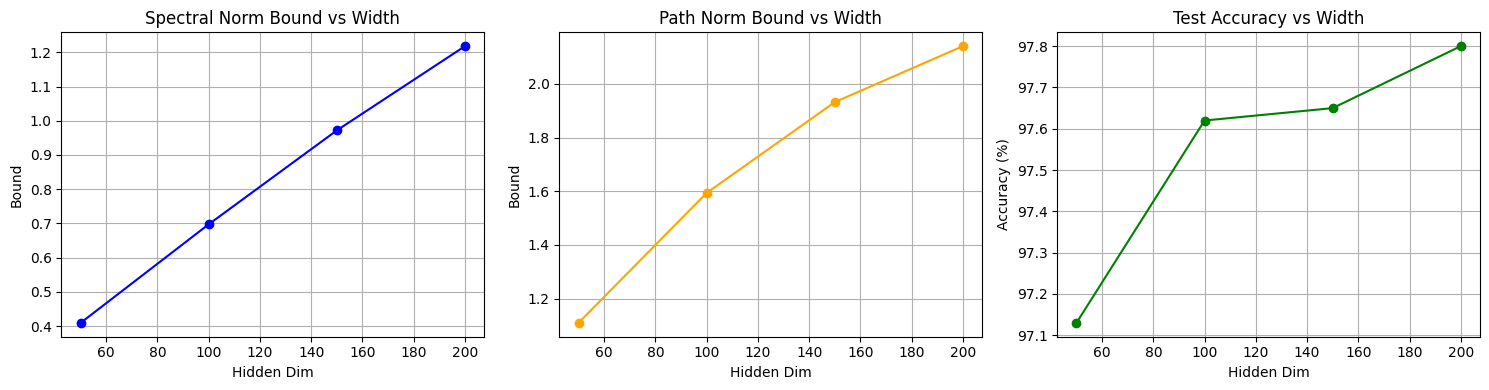

In [ ]:
hidden_dims  = [r['hidden_dim'] for r in results]
spec_bounds  = [r['spectral_bound'] for r in results]
path_bounds  = [r['path_norm_bound'] for r in results]
test_accs    = [r['final_test_accuracy'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hidden_dims, spec_bounds, marker='o', color='blue')
axes[0].set_title('Spectral Norm Bound vs Width')
axes[0].set_xlabel('Hidden Dim')
axes[0].set_ylabel('Bound')
axes[0].grid(True)

axes[1].plot(hidden_dims, path_bounds, marker='o', color='orange')
axes[1].set_title('Path Norm Bound vs Width')
axes[1].set_xlabel('Hidden Dim')
axes[1].set_ylabel('Bound')
axes[1].grid(True)

axes[2].plot(hidden_dims, test_accs, marker='o', color='green')
axes[2].set_title('Test Accuracy vs Width')
axes[2].set_xlabel('Hidden Dim')
axes[2].set_ylabel('Accuracy (%)')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('part_c_bounds.png', dpi=150)
plt.show()

### 4.b
For this part, you can work on a synthetic dataset. That is, generate a low-rank
matrix M with dimension d1 × d2, with the rank of M being r. Then, mask out (say, 90% of
the entries of M ) and use the remaining entries as the observed set. Lastly, implement the
gradient descent algorithm for matrix completion with a nuclear-norm regularization penalty
added to the mean squared objective function. Vary the the regularization level parameter
for adjusting the norm-norm regularization. Report the mean-squared reconstruction error.
Repeat the same training procedure three times, and report the mean and standard deviations
from the trained model outcomes.
[Hint: use the fact that the gradient of the nuclear norm of a matrix X is equal to U V ⊤,
where X = U DV ⊤ is the singular value decomposition of a matrix X.]
.

In [ ]:
import numpy as np

In [ ]:
# Generate a synthetic low-rank matrix M in R^{d1 x d2} with rank r.
def generate_low_rank_matrix(d1, d2, r, rng):
    left = rng.standard_normal((d1, r))
    right = rng.standard_normal((r, d2))
    return left @ right


# Mask entries: keep observed_fraction and hide the rest (e.g., 10% observed).
def mask_entries(matrix, observed_fraction, rng):
    mask = rng.random(matrix.shape) < observed_fraction
    return mask


# Gradient of nuclear norm: U V^T for X = U D V^T (SVD).
def nuclear_norm_grad(x):
    u, _, vt = np.linalg.svd(x, full_matrices=False)
    return u @ vt


# Gradient descent on mean-squared loss + lambda * ||X||_* for matrix completion.
def matrix_completion_gd(m_true, mask, lam, lr, steps):
    d1, d2 = m_true.shape
    x = np.zeros((d1, d2))
    obs_count = np.maximum(mask.sum(), 1)

    for step in range(steps):
        # Only observed entries contribute to the data-fitting term.
        residual = (x - m_true) * mask
        grad_mse = (2.0 / (d1 * d2)) * residual
        grad_nuclear = nuclear_norm_grad(x) / (d1 * d2)

        # Optional diagnostics to show relative gradient magnitudes.
        if step % 500 == 0:
            mse_grad_norm = np.linalg.norm(grad_mse)
            nuc_grad_norm = np.linalg.norm(grad_nuclear)
            print(f"step={step}, ||grad_mse||={mse_grad_norm:.4f}, ||grad_nuclear||={nuc_grad_norm:.4f}")

        x = x - lr * (grad_mse + lam * grad_nuclear)

    return x


# One training run: generate M, mask entries, fit X, and report reconstruction MSE.
def run_trial(d1, d2, r, observed_fraction, lam, lr, steps, seed):
    rng = np.random.default_rng(seed)
    m_true = generate_low_rank_matrix(d1, d2, r, rng)
    mask = mask_entries(m_true, observed_fraction, rng)
    m_hat = matrix_completion_gd(m_true, mask, lam, lr, steps)
    mse = np.mean((m_hat - m_true) ** 2)
    return mse


In [ ]:
# Synthetic matrix dimensions and rank.
d1, d2, r = 40, 50, 5

# Observe only 10% of entries (mask out 90%).
observed_fraction = 0.10

# Gradient descent settings.
lr = 1.0
steps = 5000

# Regularization levels for nuclear-norm penalty.
lambdas = [0.0, 0.1, 0.5, 1.0, 5.0, 10.0]

# Repeat training three times and summarize mean/std of MSE.
seeds = [0, 1, 2]

results = {}
for lam in lambdas:
    mses = [run_trial(d1, d2, r, observed_fraction, lam, lr, steps, seed) for seed in seeds]
    results[lam] = {
        "mses": mses,
        "mean": float(np.mean(mses)),
        "std": float(np.std(mses, ddof=1)),
    }

results


step=0, ||grad_mse||=0.0317, ||grad_nuclear||=0.0032
step=500, ||grad_mse||=0.0192, ||grad_nuclear||=0.0032
step=1000, ||grad_mse||=0.0116, ||grad_nuclear||=0.0032
step=1500, ||grad_mse||=0.0071, ||grad_nuclear||=0.0032
step=2000, ||grad_mse||=0.0043, ||grad_nuclear||=0.0032
step=2500, ||grad_mse||=0.0026, ||grad_nuclear||=0.0032
step=3000, ||grad_mse||=0.0016, ||grad_nuclear||=0.0032
step=3500, ||grad_mse||=0.0010, ||grad_nuclear||=0.0032
step=4000, ||grad_mse||=0.0006, ||grad_nuclear||=0.0032
step=4500, ||grad_mse||=0.0004, ||grad_nuclear||=0.0032
step=0, ||grad_mse||=0.0268, ||grad_nuclear||=0.0032
step=500, ||grad_mse||=0.0163, ||grad_nuclear||=0.0032
step=1000, ||grad_mse||=0.0099, ||grad_nuclear||=0.0032
step=1500, ||grad_mse||=0.0060, ||grad_nuclear||=0.0032
step=2000, ||grad_mse||=0.0036, ||grad_nuclear||=0.0032
step=2500, ||grad_mse||=0.0022, ||grad_nuclear||=0.0032
step=3000, ||grad_mse||=0.0013, ||grad_nuclear||=0.0032
step=3500, ||grad_mse||=0.0008, ||grad_nuclear||=0.0032


{0.0: {'mses': [np.float64(4.282993867395149),
   np.float64(2.845560001475827),
   np.float64(4.610020649236777)],
  'mean': 3.912858172702584,
  'std': 0.9386589736099092},
 0.1: {'mses': [np.float64(4.277036987100421),
   np.float64(2.8402994499954715),
   np.float64(4.605611053500159)],
  'mean': 3.907649163532017,
  'std': 0.9388379985479519},
 0.5: {'mses': [np.float64(4.255993749957666),
   np.float64(2.825378300340387),
   np.float64(4.593314484338864)],
  'mean': 3.8915621782123053,
  'std': 0.9386199260277661},
 1.0: {'mses': [np.float64(4.2369718491608275),
   np.float64(2.811827808804996),
   np.float64(4.583258826369213)],
  'mean': 3.877352828111679,
  'std': 0.9388750410583989},
 5.0: {'mses': [np.float64(4.222829336757452),
   np.float64(2.8134347862283486),
   np.float64(4.58048590632653)],
  'mean': 3.872250009770777,
  'std': 0.9342359518038694},
 10.0: {'mses': [np.float64(4.357034282040344),
   np.float64(2.9420928577652146),
   np.float64(4.681057379911789)],
  'm

In [ ]:
for lam in lambdas:
    entry = results[lam]
    mses = ", ".join(f"{v:.4f}" for v in entry["mses"])
    print(f"lambda={lam:.2f} | mses=[{mses}] | mean={entry['mean']:.4f} | std={entry['std']:.4f}")

lambda=0.00 | mses=[4.2830, 2.8456, 4.6100] | mean=3.9129 | std=0.9387
lambda=0.10 | mses=[4.2770, 2.8403, 4.6056] | mean=3.9076 | std=0.9388
lambda=0.50 | mses=[4.2560, 2.8254, 4.5933] | mean=3.8916 | std=0.9386
lambda=1.00 | mses=[4.2370, 2.8118, 4.5833] | mean=3.8774 | std=0.9389
lambda=5.00 | mses=[4.2228, 2.8134, 4.5805] | mean=3.8723 | std=0.9342
lambda=10.00 | mses=[4.3570, 2.9421, 4.6811] | mean=3.9934 | std=0.9248


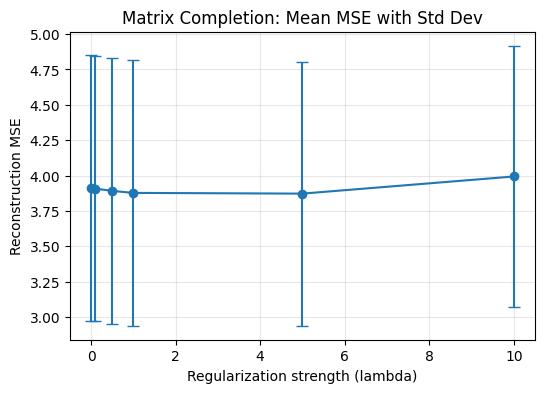

In [ ]:
import matplotlib.pyplot as plt

# Plot mean MSE vs. lambda with error bars (std across 3 runs).
plot_lambdas = sorted(results.keys())
means = [results[lam]["mean"] for lam in plot_lambdas]
stds = [results[lam]["std"] for lam in plot_lambdas]

plt.figure(figsize=(6, 4))
plt.errorbar(plot_lambdas, means, yerr=stds, fmt="o-", capsize=4)
plt.xlabel("Regularization strength (lambda)")
plt.ylabel("Reconstruction MSE")
plt.title("Matrix Completion: Mean MSE with Std Dev")
plt.grid(True, alpha=0.3)
plt.show()

